In [ ]:
 #노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Noniteractive
debconf: (Can't locate Debconf/FrontEnd/Noniteractive.pm in @INC (you may need to install the Debconf::FrontEnd::Noniteractive module) (@INC contains: /etc/perl /usr/local/lib/x86_64-linux-gnu/perl/5.34.0 /usr/local/share/perl/5.34.0 /usr/lib/x86_64-linux-gnu/perl5/5.34 /usr/share/perl5 /usr/lib/x86_64-linux-gnu/perl-base /usr/lib/x86_64-linux-gnu/perl/5.34 /usr/share/perl/5.34 /usr/local/lib/site_perl) at (eval 17) line 2, <> line 1.)
debconf: falling back to frontend: Noninteractive
Selecting previously unselected package fonts-nanum.
(Reading database ... 126374 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [1]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

In [ ]:
# -*- coding: utf-8 -*-
"""
고정 설정 버전 (자동 탐색/설정 코드 없음)
- 폰트: NanumGothic (미설치 시 OS에 설치 필요)
- 인코딩: utf-8-sig (파일이 cp949면 아래 encoding 값을 'cp949'로 바꿔주세요)
- 날짜 컬럼: '연도' (정수/연도로 가정)
- 지표 컬럼: '생산(백만톤)', '수출(백만톤)', '수입(백만톤)'
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 1) 한글 고정 폰트 설정 (자동 탐색 X)
rcParams['font.family'] = 'NanumGothic'   # OS에 설치되어 있어야 함
rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

# 2) 데이터 로드 (고정 인코딩)
file_path = "산업통상자원부_철강산업 동향_20231231.csv"  # 필요 시 절대경로로 수정
df = pd.read_csv(file_path, encoding="cp949")

# 3) 컬럼 고정 전처리
# 날짜(연도) → datetime(연도 1월 1일로 통일)
df['연도'] = pd.to_numeric(
    df['연도']
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace(" ", "", regex=False),
    errors='coerce'
).astype('Int64')

df = df.dropna(subset=['연도']).copy()
df['기준일'] = pd.to_datetime(df['연도'].astype(int).astype(str) + "-01-01")

# 수치 컬럼 고정 변환
num_cols = ['생산(백만톤)', '수출(백만톤)', '수입(백만톤)']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c]
          .astype(str)
          .str.replace(",", "", regex=False)
          .str.replace(" ", "", regex=False)
          .str.replace("%", "", regex=False)
          .str.replace("−", "-", regex=False),
        errors='coerce'
    )

# 정렬
df = df.sort_values(by='기준일').reset_index(drop=True)

# 4) 시각화 (matplotlib만 사용, 색상 지정 없음)
os.makedirs("./plots", exist_ok=True)

# (A) 연도별 추세선 (각 지표 개별 그래프)
for col in num_cols:
    plt.figure(figsize=(10, 5))
    plt.plot(df['기준일'], df[col])
    plt.title(f"[추세] {col}")
    plt.xlabel("기간"); plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"./plots/trend_{col}.png", dpi=150, bbox_inches="tight")
    plt.close()

# (B) 최신 연도 비교 막대 (3개 지표)
latest = df.iloc[-1]
latest_vals = latest[num_cols].dropna()
plt.figure(figsize=(8, 5))
latest_vals.plot(kind="bar")
plt.title(f"[최신치 비교] {latest['연도']}년")
plt.xlabel("지표"); plt.ylabel("값")
plt.tight_layout()
plt.savefig("./plots/latest_bar.png", dpi=150, bbox_inches="tight")
plt.close()

# 5) 전처리 저장
df[['연도', '기준일'] + num_cols].to_csv("./철강산업_동향_전처리(고정설정).csv",
                                     index=False, encoding="utf-8-sig")

print("완료: ./plots 폴더에 그래프 저장, 전처리 CSV 저장됨.")


완료: ./plots 폴더에 그래프 저장, 전처리 CSV 저장됨.


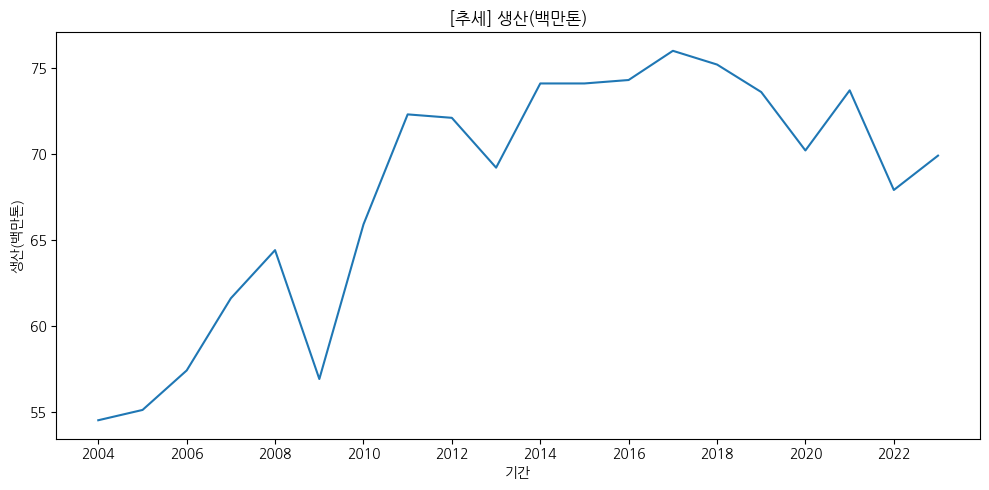

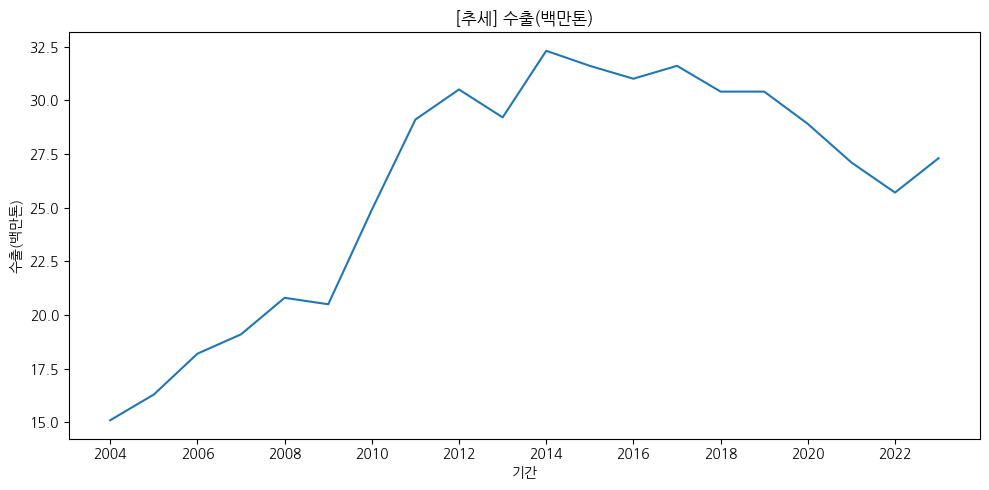

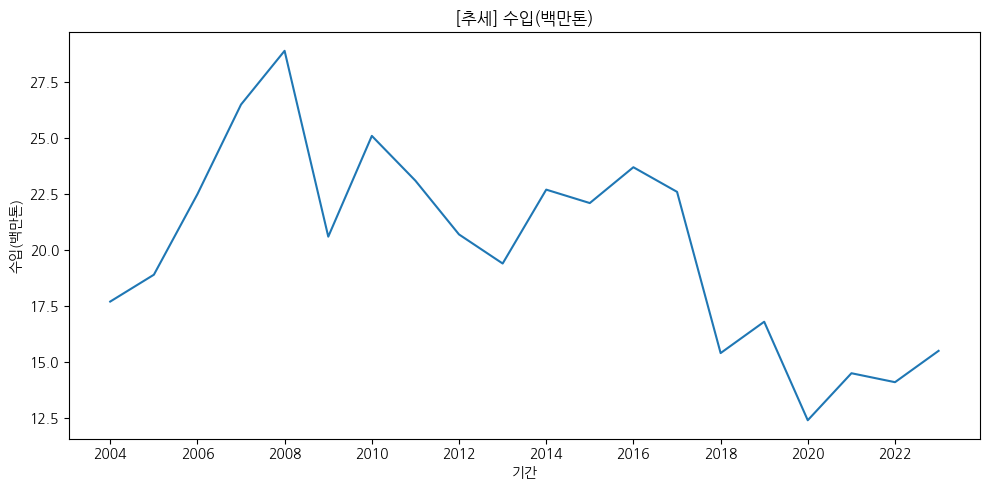

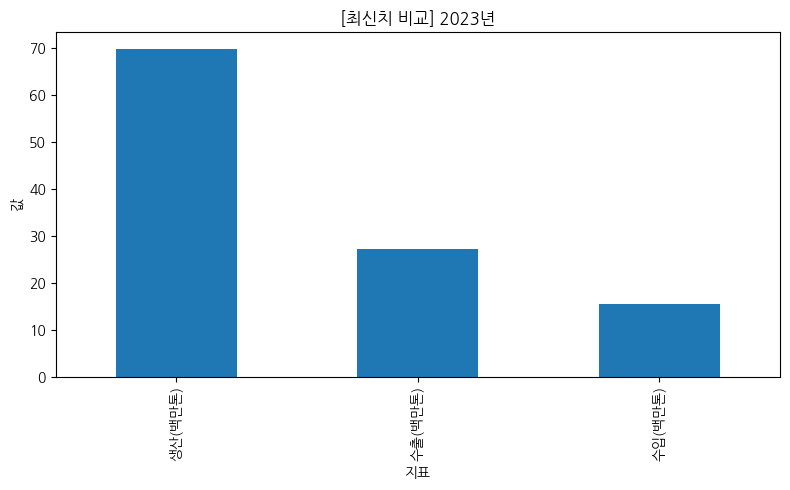

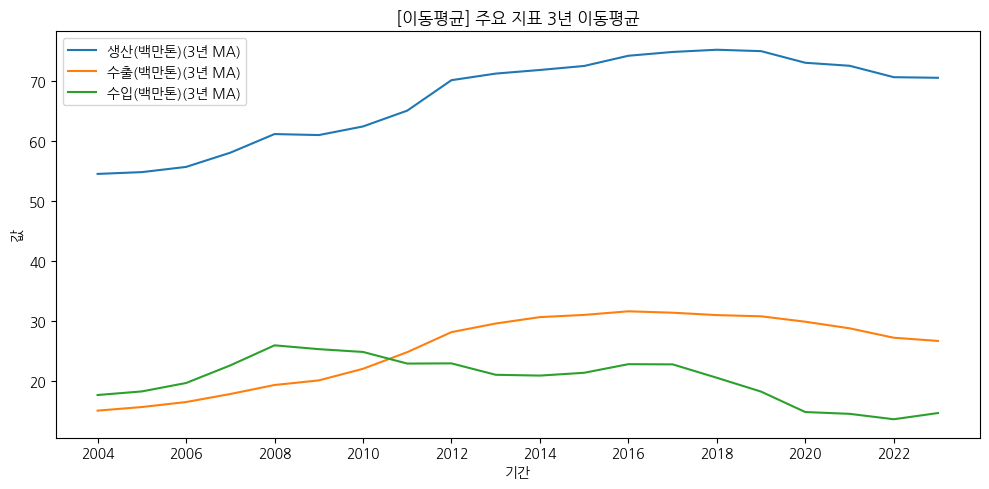

✅ 완료: 그래프가 ./plots 폴더에 저장되었습니다.


In [ ]:
# -*- coding: utf-8 -*-
"""
철강산업 동향 CSV 시각화 스크립트 (간단/명시 버전)
- 폰트: NanumGothic (OS에 설치 필요, 없으면 Noto Sans KR로 교체 가능)
- 인코딩: utf-8-sig (파일이 cp949면 encoding='cp949'로 바꾸세요)
- 고정 컬럼명: '연도', '생산(백만톤)', '수출(백만톤)', '수입(백만톤)'
- 산출물: ./plots/ 에 PNG 그래프 저장
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 0) 사용자 고정 설정 ----------------------------
FILE_PATH = "/content/산업통상자원부_철강산업 동향_20231231.csv"
YEAR_COL  = "연도"
ENCODING  = "euc-kr"
NUM_COLS  = ["생산(백만톤)", "수출(백만톤)", "수입(백만톤)"]
OUT_DIR   = "./plots"

# 1) 한글 폰트 고정 (자동 탐색 없음) ------------
rcParams["font.family"] = "NanumGothic"   # 없으면 'Noto Sans KR' 등으로 교체
rcParams["axes.unicode_minus"] = False    # 마이너스 기호 깨짐 방지

# 2) 데이터 로드 -------------------------------
df = pd.read_csv(FILE_PATH, encoding=ENCODING)

# 3) 기본 전처리 (연도→datetime, 수치 변환) -----
# 연도 정수화
df[YEAR_COL] = pd.to_numeric(
    df[YEAR_COL]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace(" ", "", regex=False),
    errors="coerce"
).astype("Int64")

# 수치 컬럼 정수/실수화
for c in NUM_COLS:
    df[c] = pd.to_numeric(
        df[c]
          .astype(str)
          .str.replace(",", "", regex=False)
          .str.replace(" ", "", regex=False)
          .str.replace("%", "", regex=False)
          .str.replace("−", "-", regex=False),
        errors="coerce"
    )

# 기준일(연초) 생성 및 정렬
df = df.dropna(subset=[YEAR_COL]).copy()
df["기준일"] = pd.to_datetime(df[YEAR_COL].astype(int).astype(str) + "-01-01")
df = df.sort_values("기준일").reset_index(drop=True)

# 4) 시각화 -----------------------------------
os.makedirs(OUT_DIR, exist_ok=True)

# (A) 지표별 연도 추세선
for col in NUM_COLS:
    plt.figure(figsize=(10, 5))
    plt.plot(df["기준일"], df[col])
    plt.title(f"[추세] {col}")
    plt.xlabel("기간")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/trend_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()

# (B) 최신 연도 기준 막대 그래프
latest = df.iloc[-1]
latest_vals = latest[NUM_COLS].dropna()
plt.figure(figsize=(8, 5))
latest_vals.plot(kind="bar")
plt.title(f"[최신치 비교] {int(latest[YEAR_COL])}년")
plt.xlabel("지표")
plt.ylabel("값")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/latest_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# (C) 3년 이동평균(부드러운 추세) 보조 그래프
MA_WINDOW = 3
ma_df = df.set_index("기준일")[NUM_COLS].rolling(MA_WINDOW, min_periods=1).mean()
plt.figure(figsize=(10, 5))
for col in NUM_COLS:
    plt.plot(ma_df.index, ma_df[col], label=f"{col}({MA_WINDOW}년 MA)")
plt.legend()
plt.title(f"[이동평균] 주요 지표 {MA_WINDOW}년 이동평균")
plt.xlabel("기간")
plt.ylabel("값")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/moving_average_{MA_WINDOW}y.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ 완료: 그래프가 ./plots 폴더에 저장되었습니다.")
